# U-Net Droplet / Nucleus Training Notebook — v8.0

### Changes from v7.0

| # | Change | Why |
|---|--------|-----|
| 1 | **Multi-label sigmoid output** (`make_multilabel_target`) | Class 1 (droplet) now covers the full droplet volume — nucleus and NPC pixels are ALSO class 1. A pixel can simultaneously be droplet AND nucleus, which is biologically correct. Replaces softmax/single-label scheme that punched holes in the droplet prediction. |
| 2 | **`make_multilabel_target` replaces `make_4class_label`** | Returns `(H, W, 4)` float32 binary array. Background, droplet, NPC, and nucleus are independent binary channels. |
| 3 | **Per-timepoint droplet segmentation parameters** (`per_timepoint_droplet_overrides`) | t=6–9 use a tighter adaptive threshold (block_size=151, offset=-0.02) to recover the ~100 late-timepoint droplets that were missed by the t=7-calibrated global params. t=0–5 retain the proven calibrated values. |
| 4 | **Parallel patch generation** (`build_training_patches_parallel`) | `ProcessPoolExecutor` runs all 10 timepoints simultaneously on separate cores. Target: 60–90 min generation replacing 6+ hours sequential. Each worker opens its own memmap, uses a seeded RNG, and writes sentinels independently. |
| 5 | **Binary cross-entropy + per-class Dice loss** | Each of the 4 channels is an independent binary segmentation problem. Replaces categorical CE + Dice. Class weights unchanged. |
| 6 | **`droplet_dice` metric added** | With solid droplet labels (no holes), droplet Dice should now be high. Tracks whether the new label scheme is learning correctly. |
| 7 | **`nucleus_score_floor` raised** `0.008 → 0.015` | Fixes t=0/1 routing to `nucleus_laplacian` instead of `npc_ring`. |
| 8 | **`min_label_fraction` lowered** `0.005 → 0.002` | Recovers late-timepoint patches that were being rejected by the too-aggressive filter. |

Everything else is unchanged from v7.0.


In [1]:
# ============================================================
# 1. Core imports
# ============================================================

from dataclasses import dataclass, field
from pathlib import Path
import os, math, time, gc, shutil, inspect
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import filters, morphology, measure
from skimage.filters import threshold_local
from skimage.measure import regionprops

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))
print("CPU count:", os.cpu_count())


2026-06-05 10:20:58.594480: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-05 10:20:58.594563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-05 10:20:58.610024: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 10:20:58.661133: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-05 10:21:12.914612: W tensorflow/compiler/tf2

TensorFlow: 2.15.1
Num GPUs Available: 1
CPU count: 128


In [2]:
# ============================================================
# 2. Configuration
# ============================================================

@dataclass
class TrainingConfig:
    # ----------------------------
    # Project paths
    # ----------------------------
    data_root: Path = Path("/home/tdeibert/Data/Machine_Learning_Dev/")
    model_root: Path = None
    image_root: Path = None
    out_root:   Path = None

    image_filename: str = "control_extract_1.1.tif"

    # ----------------------------
    # Image metadata  (T, Z, C, Y, X)
    # ----------------------------
    pixel_size_um: float = 0.108
    n_channels:    int   = 3

    membrane_channel_idx: int = 0
    nucleus_channel_idx:  int = 1
    npc_channel_idx:      int = 2

    # ----------------------------
    # Focus filtering
    # ----------------------------
    use_focus_filter:      bool  = False
    min_focus_score:       float = 0.0005
    exclude_edge_z_planes: bool  = True
    edge_z_exclusion:      int   = 2
    focus_min_z: int    = 6
    focus_max_z: object = None

    # ----------------------------
    # v7: Pre-watershed droplet seed erosion
    # ----------------------------
    droplet_seed_erosion_px: int = 10

    # ----------------------------
    # v6.6: Per-droplet focus selection (three-way adaptive)
    # v8: nucleus_score_floor raised 0.008 -> 0.015 to fix t=0/1 routing
    # ----------------------------
    use_per_droplet_focus: bool = True
    nucleus_score_floor:         float = 0.015   # v8: raised from 0.008
    nucleus_laplacian_threshold: float = 0.012
    min_droplet_focus_score:    float = 0.010
    nucleus_contrast_min_score: float = 1.5
    npc_ring_min_focus_score:   float = 0.001
    patches_per_droplet: int = 3

    # ----------------------------
    # v6.9: Nucleus presence gate
    # ----------------------------
    min_nucleus_signal_at_best_z: float = 0.0
    nucleus_signal_gate_channels: tuple = ('nucleus_laplacian', 'nucleus_contrast')

    # ----------------------------
    # v6.8: Coverslip hard-negative sampling
    # ----------------------------
    coverslip_negative_patches_per_t: int   = 20
    coverslip_z_max:                  int   = 6
    coverslip_neg_max_t:              int   = 5
    coverslip_min_brightness:         float = 0.15

    timepoint_patch_weights: object = None

    # ----------------------------
    # Droplet segmentation — global defaults
    # Calibrated on control_extract_1.1.tif at t=7
    # ----------------------------
    use_data_driven_tail:    bool  = True
    histogram_bins:          int   = 512
    histogram_smooth_window: int   = 9
    tail_start_quantile:     float = 0.80
    min_clip_quantile:       float = 0.95
    max_clip_quantile:       float = 0.995
    puncta_clip_quantile:    float = 0.985

    droplet_blur_sigma:        float = 8.0
    droplet_local_block_size:  int   = 301
    droplet_local_offset:      float = -0.05
    min_droplet_area_um2:      float = 200.0
    max_droplet_area_um2:      float = 1500.0
    droplet_hole_area_um2:     float = 10.0
    droplet_closing_radius_um: float = 3.0
    droplet_circularity_min:   float = 0.70
    droplet_eccentricity_max:  float = 0.65

    # ----------------------------
    # v8 Issue #2: Per-timepoint droplet parameter overrides
    # Format: {timepoint_int: {'local_block_size': int, 'local_offset': float}}
    # Late timepoints (t=6-9) use tighter threshold to recover complete NPC ring droplets.
    # None = use global defaults for all timepoints.
    # ----------------------------
    per_timepoint_droplet_overrides: object = None

    # ----------------------------
    # Nucleus segmentation
    # ----------------------------
    min_nucleus_area_um2:      float = 50.0
    max_nucleus_area_um2:      float = 3000.0
    nucleus_blur_sigma:        float = 1.5
    nucleus_threshold_method:  str   = "otsu"
    nucleus_closing_radius_um: float = 1.5
    nucleus_hole_area_um2:     float = 200.0
    nucleus_circularity_min:   float = 0.4
    nucleus_max_droplet_frac:  float = 0.50
    use_per_droplet_nucleus_seg: bool = True

    # ----------------------------
    # NPC detection
    # ----------------------------
    npc_ring_threshold_k: float = 2.0

    # ----------------------------
    # Patch extraction
    # v8: min_label_fraction lowered 0.005 -> 0.002 to recover late timepoint patches
    # ----------------------------
    patch_size:                   int   = 512
    patch_jitter_px:              int   = 128
    patches_per_plane:            int   = 24
    nucleus_patch_fraction:       float = 0.70
    droplet_patch_fraction:       float = 0.20
    hard_negative_patch_fraction: float = 0.10
    min_label_fraction:           float = 0.002   # v8: lowered from 0.005

    # ----------------------------
    # v8 Issue #3: Parallel patch generation
    # max_parallel_workers: number of parallel timepoint workers
    # Set to min(n_timepoints, SLURM_CPUS_PER_TASK) at runtime
    # ----------------------------
    max_parallel_workers: int = 10

    # ----------------------------
    # Model / training
    # v8: sigmoid multi-label output
    # ----------------------------
    model_name:          str   = "unet_droplet_nucleus_v8.0"
    num_classes:         int   = 4
    batch_size:          int   = 2
    epochs:              int   = 50
    learning_rate:       float = 1e-4
    validation_fraction: float = 0.20
    seed:                int   = 42

    # ----------------------------
    # Augmentation
    # ----------------------------
    use_augmentation: bool = True

    # ----------------------------
    # Loss class weights: [bg, droplet, npc_ring, nucleus_interior]
    # Applied per-channel in binary cross-entropy + Dice
    # ----------------------------
    loss_class_weights: tuple = (0.3, 0.5, 5.0, 4.0)

    val_timepoints: object = None

    def __post_init__(self):
        if self.model_root is None:
            self.model_root = self.data_root / "Models"
        if self.image_root is None:
            self.image_root = self.data_root / "Images"
        if self.out_root is None:
            self.out_root = self.data_root / "Outputs"

    @property
    def image_file(self):
        return self.image_root / self.image_filename

    @property
    def training_root(self):
        return self.out_root / f"training_patches_{self.model_name}"

    @property
    def image_patch_dir(self):
        return self.training_root / "images"

    @property
    def label_patch_dir(self):
        return self.training_root / "labels"

    @property
    def qc_dir(self):
        return self.out_root / f"qc_{self.model_name}"

    @property
    def best_model_path(self):
        return self.model_root / f"{self.model_name}_best.keras"

    @property
    def final_model_path(self):
        return self.model_root / f"{self.model_name}_final.keras"

    def patches_for_timepoint(self, t):
        if self.timepoint_patch_weights is None:
            return self.patches_per_droplet
        weights = list(self.timepoint_patch_weights)
        w = weights[t] if t < len(weights) else 1.0
        return max(1, round(self.patches_per_droplet * w))

    def droplet_kwargs_for_timepoint(self, t):
        """
        Return droplet segmentation kwargs for timepoint t.
        Merges global defaults with any per-timepoint overrides.
        Late timepoints (t=6-9) use tighter local threshold to recover
        droplets with complete bright NPC rings (Issue #2).
        """
        base = {
            "use_data_driven_tail":    self.use_data_driven_tail,
            "histogram_bins":          self.histogram_bins,
            "histogram_smooth_window": self.histogram_smooth_window,
            "tail_start_quantile":     self.tail_start_quantile,
            "min_clip_quantile":       self.min_clip_quantile,
            "max_clip_quantile":       self.max_clip_quantile,
            "blur_sigma":              self.droplet_blur_sigma,
            "local_block_size":        self.droplet_local_block_size,
            "local_offset":            self.droplet_local_offset,
            "min_droplet_area_um2":    self.min_droplet_area_um2,
            "max_droplet_area_um2":    self.max_droplet_area_um2,
            "hole_area_um2":           self.droplet_hole_area_um2,
            "closing_radius_um":       self.droplet_closing_radius_um,
            "circularity_min":         self.droplet_circularity_min,
            "eccentricity_max":        self.droplet_eccentricity_max,
        }
        if self.per_timepoint_droplet_overrides is not None:
            overrides = self.per_timepoint_droplet_overrides.get(t, {})
            base.update(overrides)
        return base


cfg = TrainingConfig()

# ── Timepoint weights ─────────────────────────────────────────────────────
cfg.timepoint_patch_weights = (0.25, 0.25, 0.5, 0.5, 1.0, 2.0, 3.0, 4.0, 4.0, 5.0)

# ── v8 Issue #2: Late timepoint droplet parameter overrides ───────────────
# t=6-9: tighter block_size for better detection of complete NPC rings
# Calibrated empirically — adjust if QC shows under/over-segmentation
cfg.per_timepoint_droplet_overrides = None

#{
    #6: {"local_block_size": 151, "local_offset": -0.02},
   # 7: {"local_block_size": 151, "local_offset": -0.02},
   # 8: {"local_block_size": 151, "local_offset": -0.02},
   # 9: {"local_block_size": 151, "local_offset": -0.02},
#}

# ── Validation split ──────────────────────────────────────────────────────
cfg.val_timepoints = [2, 5, 8]

# ── Parallel workers — set to SLURM_CPUS_PER_TASK if available ───────────
cfg.max_parallel_workers = int(os.environ.get("SLURM_CPUS_PER_TASK", 10))

for p in [
    cfg.data_root, cfg.model_root, cfg.image_root, cfg.out_root,
    cfg.training_root, cfg.image_patch_dir, cfg.label_patch_dir, cfg.qc_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

DATA_ROOT     = cfg.data_root
MODEL_ROOT    = cfg.model_root
IMAGE_ROOT    = cfg.image_root
OUT_ROOT      = cfg.out_root
IMAGE_FILE    = cfg.image_file
PIXEL_SIZE_UM = cfg.pixel_size_um
MEM_CH        = cfg.membrane_channel_idx
NUC_CH        = cfg.nucleus_channel_idx
NPC_CH        = cfg.npc_channel_idx
PATCH_SIZE    = cfg.patch_size
NUM_CHANNELS  = cfg.n_channels
NUM_CLASSES   = cfg.num_classes
BATCH_SIZE    = cfg.batch_size

print("DATA_ROOT              :", DATA_ROOT)
print("IMAGE_FILE             :", IMAGE_FILE)
print("MODEL_ROOT             :", MODEL_ROOT)
print("nucleus_score_floor    :", cfg.nucleus_score_floor)
print("min_label_fraction     :", cfg.min_label_fraction)
print("max_parallel_workers   :", cfg.max_parallel_workers)
print("per_timepoint_overrides:", cfg.per_timepoint_droplet_overrides)
print("timepoint_weights      :", cfg.timepoint_patch_weights)
print(f"patches_per_droplet    : {cfg.patches_per_droplet} base",
      f"(weighted: {[cfg.patches_for_timepoint(t) for t in range(10)]} for t0-t9)")
print("\nDroplet kwargs per timepoint:")
for t_check in [0, 5, 6, 9]:
    dk = cfg.droplet_kwargs_for_timepoint(t_check)
    print(f"  t={t_check}: block_size={dk['local_block_size']}  offset={dk['local_offset']}")


DATA_ROOT              : /home/tdeibert/Data/Machine_Learning_Dev
IMAGE_FILE             : /home/tdeibert/Data/Machine_Learning_Dev/Images/control_extract_1.1.tif
MODEL_ROOT             : /home/tdeibert/Data/Machine_Learning_Dev/Models
nucleus_score_floor    : 0.015
min_label_fraction     : 0.002
max_parallel_workers   : 10
per_timepoint_overrides: None
timepoint_weights      : (0.25, 0.25, 0.5, 0.5, 1.0, 2.0, 3.0, 4.0, 4.0, 5.0)
patches_per_droplet    : 3 base (weighted: [1, 1, 2, 2, 3, 6, 9, 12, 12, 15] for t0-t9)

Droplet kwargs per timepoint:
  t=0: block_size=301  offset=-0.05
  t=5: block_size=301  offset=-0.05
  t=6: block_size=301  offset=-0.05
  t=9: block_size=301  offset=-0.05


In [3]:
# ============================================================
# 3. Memory-mapped TIFF loading
# ============================================================

def load_memmap_tiff(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find TIFF file: {path}")
    arr = tiff.memmap(str(path))
    print("Loaded memory-mapped TIFF")
    print("  Path :", path)
    print("  Shape:", arr.shape)
    print("  Dtype:", arr.dtype)
    return arr

img_fov = load_memmap_tiff(IMAGE_FILE)
img = img_fov

if img_fov.ndim != 5:
    raise ValueError(f"Expected shape (T, Z, C, Y, X), got {img_fov.shape}")

print("Image shape:", img_fov.shape)
print("Image dtype:", img_fov.dtype)


Loaded memory-mapped TIFF
  Path : /home/tdeibert/Data/Machine_Learning_Dev/Images/control_extract_1.1.tif
  Shape: (10, 20, 3, 3889, 5732)
  Dtype: >u2
Image shape: (10, 20, 3, 3889, 5732)
Image dtype: >u2


In [ ]:
# ============================================================
# 4. Simple viewer: one timepoint, one Z plane, all channels
# ============================================================

def show_plane_all_channels(img, t=0, z=0, channel_names=None, percentile=(1, 99.8)):
    plane = img[t, z]
    C = plane.shape[0]
    if channel_names is None:
        channel_names = [f"Channel {i}" for i in range(C)]
    fig, axes = plt.subplots(1, C, figsize=(5 * C, 5))
    if C == 1:
        axes = [axes]
    for c in range(C):
        arr = np.asarray(plane[c])
        lo, hi = np.percentile(arr, percentile)
        axes[c].imshow(arr, cmap="gray", vmin=lo, vmax=hi)
        axes[c].set_title(f"{channel_names[c]} | t={t}, z={z}")
        axes[c].axis("off")
    plt.tight_layout()
    plt.show()

show_plane_all_channels(
    img_fov, t=0,
    z=min(10, img_fov.shape[1] - 1),
    channel_names=["Membrane / context", "Nucleus (NLS)", "NPC"],
)


In [4]:
# ============================================================
# 5. Segmentation utilities: units, normalization, focus
# (unchanged from v7)
# ============================================================

def area_um2_to_px(area_um2, pixel_size_um=PIXEL_SIZE_UM):
    if area_um2 is None:
        return None
    return int(np.ceil(area_um2 / (pixel_size_um ** 2)))

def radius_um_to_px(radius_um, pixel_size_um=PIXEL_SIZE_UM):
    if radius_um is None:
        return 0
    return max(1, int(np.ceil(radius_um / pixel_size_um)))

def normalize_01(img2d):
    arr = img2d.astype('float32', copy=False)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    if hi <= lo:
        return np.zeros_like(arr, dtype='float32')
    return (arr - lo) / (hi - lo)

def normalize_channel(ch2d):
    return normalize_01(ch2d).astype('float32')

def focus_score_variance_laplacian(img2d):
    img_f = normalize_01(img2d)
    lap = ndi.laplace(img_f)
    return float(np.var(lap))

def z_plane_allowed(z, n_z, exclude_edge_z=cfg.edge_z_exclusion):
    if exclude_edge_z is None or exclude_edge_z <= 0:
        return True
    return exclude_edge_z <= z < (n_z - exclude_edge_z)

def z_in_focus_range(z, n_z, cfg=cfg):
    if cfg.exclude_edge_z_planes and not z_plane_allowed(z, n_z, cfg.edge_z_exclusion):
        return False
    if cfg.focus_min_z is not None and z < cfg.focus_min_z:
        return False
    if cfg.focus_max_z is not None and z > cfg.focus_max_z:
        return False
    return True

def plane_passes_focus(nuc2d, min_focus_score=cfg.min_focus_score):
    score = focus_score_variance_laplacian(nuc2d)
    return score >= min_focus_score, score

def filter_objects_by_area(mask, pixel_size_um, min_area_um2=None, max_area_um2=None):
    labeled = measure.label(mask)
    clean = np.zeros_like(mask, dtype=bool)
    min_px = 0 if min_area_um2 is None else area_um2_to_px(min_area_um2, pixel_size_um)
    max_px = np.inf if max_area_um2 is None else area_um2_to_px(max_area_um2, pixel_size_um)
    for region in measure.regionprops(labeled):
        if min_px <= region.area <= max_px:
            clean[labeled == region.label] = True
    return clean


def per_droplet_focus_scores_nucleus_laplacian(nuc2d, droplet_mask, erosion_radius_px=None):
    if erosion_radius_px is None:
        erosion_radius_px = cfg.droplet_seed_erosion_px
    labeled = measure.label(droplet_mask)
    nuc_f = normalize_01(nuc2d)
    laplacian_sq = ndi.laplace(nuc_f) ** 2
    dist = ndi.distance_transform_edt(droplet_mask.astype(bool))
    eroded_mask = dist >= erosion_radius_px
    eroded_labels = labeled * eroded_mask.astype(np.int32)
    ids = np.unique(eroded_labels)[1:]
    if len(ids) == 0:
        return {}
    scores = ndi.mean(laplacian_sq, labels=eroded_labels, index=ids)
    return dict(zip(ids.tolist(), scores.tolist()))


def per_droplet_focus_scores_nucleus_contrast(nuc2d, droplet_mask, erosion_radius_px=None):
    if erosion_radius_px is None:
        erosion_radius_px = cfg.droplet_seed_erosion_px
    labeled = measure.label(droplet_mask)
    nuc_f = normalize_01(nuc2d)
    dist = ndi.distance_transform_edt(droplet_mask.astype(bool))
    interior_mask = dist >= erosion_radius_px
    ring_mask     = droplet_mask.astype(bool) & ~interior_mask
    ids = np.unique(labeled)[1:]
    scores = {}
    for label_id in ids:
        droplet_interior = interior_mask & (labeled == label_id)
        droplet_ring     = ring_mask     & (labeled == label_id)
        if not droplet_interior.any() or not droplet_ring.any():
            continue
        mean_interior = float(np.mean(nuc_f[droplet_interior]))
        mean_ring     = float(np.mean(nuc_f[droplet_ring]))
        scores[int(label_id)] = mean_interior / (mean_ring + 1e-6)
    return scores


def per_droplet_focus_scores_npc_ring(npc2d, droplet_mask, erosion_radius_px=None):
    if erosion_radius_px is None:
        erosion_radius_px = cfg.droplet_seed_erosion_px
    labeled = measure.label(droplet_mask)
    npc_f = normalize_01(npc2d)
    laplacian_sq = ndi.laplace(npc_f) ** 2
    dist = ndi.distance_transform_edt(droplet_mask.astype(bool))
    interior_mask = dist >= erosion_radius_px
    ring_mask     = droplet_mask.astype(bool) & ~interior_mask
    ring_labels   = labeled * ring_mask.astype(np.int32)
    ids = np.unique(ring_labels)[1:]
    if len(ids) == 0:
        return {}
    scores = ndi.mean(laplacian_sq, labels=ring_labels, index=ids)
    return dict(zip(ids.tolist(), scores.tolist()))


def droplet_has_nucleus_signal(nuc2d, droplet_binary, erosion_radius_px, cfg=cfg):
    interior = ndi.binary_erosion(droplet_binary.astype(bool), iterations=erosion_radius_px)
    if not interior.any():
        return False, 0.0
    nuc_f = normalize_01(nuc2d)
    mean_intensity = float(np.mean(nuc_f[interior]))
    return mean_intensity >= cfg.min_nucleus_signal_at_best_z, mean_intensity


def select_focus_channel(img_fov, t, droplet_mask_ref, cfg=cfg):
    n_z = img_fov.shape[1]
    peak_scores = []
    for z in range(n_z):
        if not z_in_focus_range(z, n_z, cfg=cfg):
            continue
        nuc2d = np.asarray(img_fov[t, z, cfg.nucleus_channel_idx])
        z_scores = per_droplet_focus_scores_nucleus_laplacian(
            nuc2d, droplet_mask_ref, erosion_radius_px=cfg.droplet_seed_erosion_px)
        if z_scores:
            peak_scores.append(max(z_scores.values()))
    peak_lap = float(np.max(peak_scores)) if peak_scores else 0.0
    if peak_lap < cfg.nucleus_score_floor:
        channel = 'npc_ring'
    elif peak_lap < cfg.nucleus_laplacian_threshold:
        channel = 'nucleus_contrast'
    else:
        channel = 'nucleus_laplacian'
    return channel, peak_lap


def select_best_focus_z_per_droplet(img_fov, t, droplet_mask_ref,
                                    erosion_radius_px=None, cfg=cfg):
    if erosion_radius_px is None:
        erosion_radius_px = cfg.droplet_seed_erosion_px
    channel, peak_lap = select_focus_channel(img_fov, t, droplet_mask_ref, cfg=cfg)
    min_score = {
        'npc_ring':          cfg.npc_ring_min_focus_score,
        'nucleus_contrast':  cfg.nucleus_contrast_min_score,
        'nucleus_laplacian': cfg.min_droplet_focus_score,
    }[channel]
    labeled_ref = measure.label(droplet_mask_ref)
    droplet_ids = set(np.unique(labeled_ref)[1:].tolist())
    if not droplet_ids:
        return {}, channel, {}
    n_z = img_fov.shape[1]
    score_matrix = {did: {} for did in droplet_ids}
    dist_ref      = ndi.distance_transform_edt(droplet_mask_ref.astype(bool))
    interior_ref  = dist_ref >= erosion_radius_px
    ring_mask_ref = droplet_mask_ref.astype(bool) & ~interior_ref
    eroded_labels_ref = labeled_ref * interior_ref.astype(np.int32)
    ring_labels_ref   = labeled_ref * ring_mask_ref.astype(np.int32)
    ids_interior = np.unique(eroded_labels_ref)[1:]
    ids_ring     = np.unique(ring_labels_ref)[1:]
    for z in range(n_z):
        if not z_in_focus_range(z, n_z, cfg=cfg):
            continue
        if channel == 'npc_ring':
            ch2d  = np.asarray(img_fov[t, z, cfg.npc_channel_idx])
            npc_f = normalize_01(ch2d)
            lap_sq = ndi.laplace(npc_f) ** 2
            if len(ids_ring) == 0:
                z_scores = {}
            else:
                sc = ndi.mean(lap_sq, labels=ring_labels_ref, index=ids_ring)
                z_scores = dict(zip(ids_ring.tolist(), sc.tolist()))
        elif channel == 'nucleus_contrast':
            ch2d  = np.asarray(img_fov[t, z, cfg.nucleus_channel_idx])
            nuc_f = normalize_01(ch2d)
            if len(ids_interior) == 0 or len(ids_ring) == 0:
                z_scores = {}
            else:
                m_int  = ndi.mean(nuc_f, labels=eroded_labels_ref, index=ids_interior)
                m_ring = ndi.mean(nuc_f, labels=ring_labels_ref,   index=ids_ring)
                z_scores = {
                    int(did): float(mi) / (float(mr) + 1e-6)
                    for did, mi, mr in zip(ids_interior, m_int, m_ring)
                }
        else:
            ch2d  = np.asarray(img_fov[t, z, cfg.nucleus_channel_idx])
            nuc_f = normalize_01(ch2d)
            lap_sq = ndi.laplace(nuc_f) ** 2
            if len(ids_interior) == 0:
                z_scores = {}
            else:
                sc = ndi.mean(lap_sq, labels=eroded_labels_ref, index=ids_interior)
                z_scores = dict(zip(ids_interior.tolist(), sc.tolist()))
        for did, score in z_scores.items():
            if did in score_matrix:
                score_matrix[did][z] = score
    labeled_ref_full = measure.label(droplet_mask_ref)
    best_z = {}
    nucleus_signals = {}
    for did, z_scores in score_matrix.items():
        if not z_scores:
            continue
        bz = max(z_scores, key=z_scores.get)
        if z_scores[bz] < min_score:
            continue
        nuc_at_bz      = np.asarray(img_fov[t, bz, cfg.nucleus_channel_idx])
        droplet_binary = labeled_ref_full == did
        _, sig = droplet_has_nucleus_signal(nuc_at_bz, droplet_binary, erosion_radius_px, cfg=cfg)
        nucleus_signals[int(did)] = sig
        if (cfg.min_nucleus_signal_at_best_z > 0
                and channel in cfg.nucleus_signal_gate_channels
                and not sig >= cfg.min_nucleus_signal_at_best_z):
            continue
        best_z[int(did)] = int(bz)
    return best_z, channel, nucleus_signals


def get_reference_z(img_fov, t, cfg=cfg, droplet_kwargs=None):
    dk = droplet_kwargs or {}
    n_z = img_fov.shape[1]
    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    if not valid_zs:
        return n_z // 2, 0, None
    ref_z = valid_zs[len(valid_zs) // 2]
    npc2d = np.asarray(img_fov[t, ref_z, cfg.npc_channel_idx])
    mask  = segment_droplet_from_npc(npc2d, pixel_size_um=cfg.pixel_size_um, **dk)
    n = len(np.unique(measure.label(mask))) - 1
    return ref_z, n, mask


print("50 um2 nucleus minimum =", area_um2_to_px(50, PIXEL_SIZE_UM), "px")
print("512 px patch FOV =", PATCH_SIZE * PIXEL_SIZE_UM, "um")
print("Seed erosion radius =", cfg.droplet_seed_erosion_px, "px /",
      round(cfg.droplet_seed_erosion_px * cfg.pixel_size_um, 2), "um")


50 um2 nucleus minimum = 4287 px
512 px patch FOV = 55.296 um
Seed erosion radius = 10 px / 1.08 um


In [5]:
# ============================================================
# 6. Data-driven NPC puncta clipping
# (unchanged from v7)
# ============================================================

def estimate_npc_histogram_tail_cutoff(
    npc2d,
    bins=cfg.histogram_bins,
    smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
):
    npc_f = normalize_01(npc2d)
    vals  = npc_f[np.isfinite(npc_f)].ravel()
    vals  = vals[vals > 0]
    if vals.size == 0:
        return 1.0, 1.0, {"reason": "empty_nonzero_values", "cutoff_value": 1.0, "cutoff_quantile": 1.0}
    hist, edges = np.histogram(vals, bins=bins, range=(0, 1))
    centers     = (edges[:-1] + edges[1:]) / 2
    smooth_window = int(max(3, smooth_window))
    if smooth_window % 2 == 0:
        smooth_window += 1
    kernel      = np.ones(smooth_window, dtype='float32') / smooth_window
    hist_smooth = np.convolve(hist.astype('float32'), kernel, mode='same')
    log_hist    = np.log1p(hist_smooth)
    slope       = np.gradient(log_hist, centers)
    tail_start  = np.quantile(vals, tail_start_quantile)
    tail_mask   = centers >= tail_start
    if tail_mask.sum() < smooth_window:
        cutoff_quantile = max_clip_quantile
        cutoff_value    = float(np.quantile(vals, cutoff_quantile))
        reason          = "fallback_insufficient_tail_bins"
    else:
        tail_centers   = centers[tail_mask]
        tail_slope     = slope[tail_mask]
        slope_smooth   = np.convolve(tail_slope, kernel, mode='same')
        tail_idx       = int(np.argmin(slope_smooth))
        raw_cutoff_val = float(tail_centers[tail_idx])
        raw_cutoff_q   = float(np.mean(vals <= raw_cutoff_val))
        cutoff_quantile = float(np.clip(raw_cutoff_q, min_clip_quantile, max_clip_quantile))
        cutoff_value    = float(np.quantile(vals, cutoff_quantile))
        reason          = "sliding_window_histogram_tail"
    debug = {
        "hist": hist, "hist_smooth": hist_smooth, "centers": centers, "slope": slope,
        "tail_start": float(tail_start), "cutoff_value": float(cutoff_value),
        "cutoff_quantile": float(cutoff_quantile), "reason": reason,
    }
    return cutoff_value, cutoff_quantile, debug


def clip_npc_puncta_data_driven(
    npc2d,
    bins=cfg.histogram_bins,
    smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
):
    npc_f = normalize_01(npc2d)
    cutoff_value, cutoff_quantile, debug = estimate_npc_histogram_tail_cutoff(
        npc_f, bins=bins, smooth_window=smooth_window,
        tail_start_quantile=tail_start_quantile,
        min_clip_quantile=min_clip_quantile,
        max_clip_quantile=max_clip_quantile,
    )
    npc_clean = npc_f.copy()
    npc_clean[npc_clean > cutoff_value] = cutoff_value
    npc_clean = normalize_01(npc_clean)
    return npc_clean, cutoff_value, cutoff_quantile, debug


In [6]:
# ============================================================
# 7. Segmentation functions
# v8: make_multilabel_target replaces make_4class_label
# Droplet class now covers full circle — nucleus/NPC pixels
# are simultaneously class 1 (droplet) AND their own class.
# ============================================================

def segment_droplet_from_npc(
    npc2d, pixel_size_um=PIXEL_SIZE_UM,
    use_data_driven_tail=cfg.use_data_driven_tail,
    puncta_clip_quantile=cfg.puncta_clip_quantile,
    histogram_bins=cfg.histogram_bins,
    histogram_smooth_window=cfg.histogram_smooth_window,
    tail_start_quantile=cfg.tail_start_quantile,
    min_clip_quantile=cfg.min_clip_quantile,
    max_clip_quantile=cfg.max_clip_quantile,
    blur_sigma=cfg.droplet_blur_sigma,
    local_block_size=cfg.droplet_local_block_size,
    local_offset=cfg.droplet_local_offset,
    min_droplet_area_um2=cfg.min_droplet_area_um2,
    max_droplet_area_um2=cfg.max_droplet_area_um2,
    hole_area_um2=cfg.droplet_hole_area_um2,
    closing_radius_um=cfg.droplet_closing_radius_um,
    circularity_min=cfg.droplet_circularity_min,
    eccentricity_max=cfg.droplet_eccentricity_max,
    return_debug=False, **unused_kwargs,
):
    npc_f = normalize_01(npc2d)
    if use_data_driven_tail:
        npc_clean, clip_value, clip_quantile, puncta_debug = clip_npc_puncta_data_driven(
            npc2d, bins=histogram_bins, smooth_window=histogram_smooth_window,
            tail_start_quantile=tail_start_quantile,
            min_clip_quantile=min_clip_quantile,
            max_clip_quantile=max_clip_quantile,
        )
        clip_method = "data_driven_histogram_tail"
    else:
        clip_value    = float(np.quantile(npc_f, puncta_clip_quantile))
        clip_quantile = float(puncta_clip_quantile)
        npc_clean     = npc_f.copy()
        npc_clean[npc_clean > clip_value] = clip_value
        npc_clean     = normalize_01(npc_clean)
        puncta_debug  = {"cutoff_value": clip_value, "cutoff_quantile": clip_quantile,
                         "reason": "fixed_quantile_fallback"}
        clip_method   = "fixed_quantile"

    npc_blur  = filters.gaussian(npc_clean, sigma=blur_sigma, preserve_range=True)
    npc_field = normalize_01(npc_blur)
    block_size = int(max(3, local_block_size))
    if block_size % 2 == 0:
        block_size += 1
    local_thresh  = threshold_local(npc_field, block_size=block_size, offset=local_offset)
    droplet_mask  = npc_field > local_thresh
    if closing_radius_um and closing_radius_um > 0:
        droplet_mask = morphology.binary_closing(
            droplet_mask, morphology.disk(radius_um_to_px(closing_radius_um, pixel_size_um)))
    if hole_area_um2 and hole_area_um2 > 0:
        droplet_mask = morphology.remove_small_holes(
            droplet_mask, area_threshold=area_um2_to_px(hole_area_um2, pixel_size_um))
    if min_droplet_area_um2 and min_droplet_area_um2 > 0:
        droplet_mask = morphology.remove_small_objects(
            droplet_mask, min_size=area_um2_to_px(min_droplet_area_um2, pixel_size_um))
    labeled = measure.label(droplet_mask)
    filtered = np.zeros_like(droplet_mask, dtype=bool)
    max_area_px = area_um2_to_px(max_droplet_area_um2, pixel_size_um) if max_droplet_area_um2 else np.inf
    for region in measure.regionprops(labeled):
        if region.area > max_area_px:
            continue
        if region.perimeter == 0:
            continue
        circ = (4 * np.pi * region.area) / (region.perimeter ** 2)
        if circ < circularity_min:
            continue
        if region.eccentricity > eccentricity_max:
            continue
        filtered[labeled == region.label] = True
    droplet_mask = filtered
    if return_debug:
        return droplet_mask, {
            "npc_norm": npc_f, "npc_clean": npc_clean, "npc_blur": npc_blur,
            "npc_field": npc_field, "local_thresh": local_thresh,
            "clip_method": clip_method, "clip_value": float(clip_value),
            "clip_quantile": float(clip_quantile), "puncta_debug": puncta_debug,
            "threshold": None, "threshold_method": "local",
            "local_block_size": block_size, "local_offset": float(local_offset),
            "min_droplet_area_px": area_um2_to_px(min_droplet_area_um2, pixel_size_um),
            "unused_kwargs": unused_kwargs,
        }
    return droplet_mask


def segment_nucleus_from_import(
    nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    min_nucleus_area_um2=cfg.min_nucleus_area_um2,
    max_nucleus_area_um2=cfg.max_nucleus_area_um2,
    blur_sigma=cfg.nucleus_blur_sigma,
    threshold_method=cfg.nucleus_threshold_method,
    closing_radius_um=cfg.nucleus_closing_radius_um,
    hole_area_um2=cfg.nucleus_hole_area_um2,
    return_debug=False, **unused_kwargs,
):
    """Global nucleus segmentation — retained for ablation."""
    nuc_f    = normalize_01(nuc2d)
    nuc_blur = filters.gaussian(nuc_f, sigma=blur_sigma, preserve_range=True)
    if threshold_method == "otsu":
        thr = filters.threshold_otsu(nuc_blur)
    elif threshold_method == "yen":
        thr = filters.threshold_yen(nuc_blur)
    else:
        thr = filters.threshold_li(nuc_blur)
    nucleus_mask = nuc_blur > thr
    if closing_radius_um and closing_radius_um > 0:
        nucleus_mask = morphology.binary_closing(
            nucleus_mask, morphology.disk(radius_um_to_px(closing_radius_um, pixel_size_um)))
    nucleus_mask = ndi.binary_fill_holes(nucleus_mask)
    if hole_area_um2 and hole_area_um2 > 0:
        nucleus_mask = morphology.remove_small_holes(
            nucleus_mask, area_threshold=area_um2_to_px(hole_area_um2, pixel_size_um))
    nucleus_mask = filter_objects_by_area(
        nucleus_mask, pixel_size_um=pixel_size_um,
        min_area_um2=min_nucleus_area_um2, max_area_um2=max_nucleus_area_um2)
    return nucleus_mask.astype(bool)


def segment_nucleus_per_droplet(
    nuc2d, droplet_mask, pixel_size_um=PIXEL_SIZE_UM,
    min_nucleus_area_um2=cfg.min_nucleus_area_um2,
    max_nucleus_area_um2=cfg.max_nucleus_area_um2,
    blur_sigma=cfg.nucleus_blur_sigma,
    closing_radius_um=cfg.nucleus_closing_radius_um,
    hole_area_um2=cfg.nucleus_hole_area_um2,
    circularity_min=cfg.nucleus_circularity_min,
    max_droplet_frac=cfg.nucleus_max_droplet_frac,
):
    labeled_droplets = measure.label(droplet_mask)
    nucleus_mask_out = np.zeros_like(droplet_mask, dtype=bool)
    nuc_f    = normalize_01(nuc2d)
    nuc_blur = filters.gaussian(nuc_f, sigma=blur_sigma, preserve_range=True)
    for region in measure.regionprops(labeled_droplets):
        droplet_binary = labeled_droplets == region.label
        interior_vals  = nuc_blur[droplet_binary]
        val_range      = interior_vals.max() - interior_vals.min()
        if val_range < 1e-6:
            continue
        try:
            thr = filters.threshold_otsu(interior_vals)
        except Exception:
            continue
        local_mask = np.zeros_like(droplet_mask, dtype=bool)
        local_mask[droplet_binary] = nuc_blur[droplet_binary] > thr
        if closing_radius_um and closing_radius_um > 0:
            local_mask = morphology.binary_closing(
                local_mask, morphology.disk(radius_um_to_px(closing_radius_um, pixel_size_um)))
        local_mask = ndi.binary_fill_holes(local_mask)
        if hole_area_um2 and hole_area_um2 > 0:
            local_mask = morphology.remove_small_holes(
                local_mask, area_threshold=area_um2_to_px(hole_area_um2, pixel_size_um))
        local_mask = filter_objects_by_area(
            local_mask, pixel_size_um=pixel_size_um,
            min_area_um2=min_nucleus_area_um2, max_area_um2=max_nucleus_area_um2)
        labeled_nuc = measure.label(local_mask)
        for nuc_region in measure.regionprops(labeled_nuc):
            if nuc_region.area / region.area > max_droplet_frac:
                continue
            if nuc_region.perimeter == 0:
                continue
            circ = (4 * np.pi * nuc_region.area) / (nuc_region.perimeter ** 2)
            if circ < circularity_min:
                continue
            nucleus_mask_out[labeled_nuc == nuc_region.label] = True
    return nucleus_mask_out


def detect_npc_per_droplet(
    npc2d, droplet_mask, pixel_size_um=PIXEL_SIZE_UM,
    threshold_k=None,
):
    if threshold_k is None:
        threshold_k = cfg.npc_ring_threshold_k
    npc_f            = normalize_01(npc2d)
    labeled_droplets = measure.label(droplet_mask)
    npc_mask         = np.zeros_like(droplet_mask, dtype=bool)
    ids = np.unique(labeled_droplets)[1:]
    if len(ids) == 0:
        return npc_mask
    means = ndi.mean(npc_f,               labels=labeled_droplets, index=ids)
    stds  = ndi.standard_deviation(npc_f, labels=labeled_droplets, index=ids)
    for i, did in enumerate(ids):
        thr          = means[i] + threshold_k * stds[i]
        droplet_zone = labeled_droplets == did
        npc_mask[droplet_zone] = npc_f[droplet_zone] > thr
    return npc_mask


def make_multilabel_target(
    npc2d, nuc2d, droplet_mask, pixel_size_um=PIXEL_SIZE_UM,
    nucleus_kwargs=None, threshold_k=None,
    enforce_nucleus_inside_droplet=True,
):
    """
    v8: Build a 4-channel multi-label binary target of shape (H, W, 4).

    Channel definitions
    -------------------
    0 : Background  — 1 outside all droplets, 0 inside
    1 : Droplet     — 1 for ALL pixels inside any droplet (base layer).
                      NEVER set to 0 inside a droplet. Nucleus and NPC
                      pixels are simultaneously class 1.
    2 : NPC signal  — 1 where NPC detected (also class 1)
    3 : Nucleus     — 1 where nucleus detected (also class 1)

    This is biologically correct: a nucleus is inside a droplet.
    The previous single-label scheme forced mutual exclusion and created
    holes in the droplet prediction wherever nucleus/NPC was assigned.

    Returns float32 array of shape (H, W, 4) with values in {0.0, 1.0}.
    """
    nucleus_kwargs = nucleus_kwargs or {}
    nk_filtered = {k: v for k, v in nucleus_kwargs.items()
                   if k in ('min_nucleus_area_um2', 'max_nucleus_area_um2',
                            'blur_sigma', 'closing_radius_um', 'hole_area_um2')}
    H, W = droplet_mask.shape
    target = np.zeros((H, W, 4), dtype=np.float32)

    # Ch 0: background — outside all droplets
    target[..., 0] = (~droplet_mask).astype(np.float32)

    # Ch 1: droplet interior — full filled circle, never erased
    target[..., 1] = droplet_mask.astype(np.float32)

    # Ch 2: NPC signal — also inside droplet, so ch1 stays 1
    npc_mask = detect_npc_per_droplet(
        npc2d, droplet_mask, pixel_size_um=pixel_size_um, threshold_k=threshold_k)
    target[..., 2] = npc_mask.astype(np.float32)

    # Ch 3: nucleus interior — also inside droplet, so ch1 stays 1
    if cfg.use_per_droplet_nucleus_seg:
        nucleus_mask = segment_nucleus_per_droplet(
            nuc2d, droplet_mask, pixel_size_um=pixel_size_um, **nk_filtered)
    else:
        nucleus_mask = segment_nucleus_from_import(
            nuc2d, pixel_size_um=pixel_size_um, **nucleus_kwargs)
    if enforce_nucleus_inside_droplet:
        nucleus_mask = nucleus_mask & droplet_mask
    target[..., 3] = nucleus_mask.astype(np.float32)

    return target, npc_mask, nucleus_mask


def build_training_label_plane(
    npc2d, nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    min_focus_score=cfg.min_focus_score,
    use_focus_filter=cfg.use_focus_filter,
    droplet_kwargs=None, nucleus_kwargs=None,
    enforce_nucleus_inside_droplet=True,
):
    """
    Build a multi-label target for one Z-plane.
    Returns (target_hwc, metadata, debug) where target_hwc is (H, W, 4) float32.
    """
    droplet_kwargs = droplet_kwargs or {}
    nucleus_kwargs = nucleus_kwargs or {}
    focus_pass, focus_score = plane_passes_focus(nuc2d, min_focus_score=min_focus_score)
    if use_focus_filter and not focus_pass:
        return None, {"focus_pass": False, "focus_score": focus_score,
                      "droplet_area_px": 0, "nucleus_area_px": 0,
                      "reason": "out_of_focus"}, None
    droplet_mask, droplet_debug = segment_droplet_from_npc(
        npc2d, pixel_size_um=pixel_size_um, return_debug=True, **droplet_kwargs)
    target, npc_mask, nucleus_mask = make_multilabel_target(
        npc2d=npc2d, nuc2d=nuc2d, droplet_mask=droplet_mask,
        pixel_size_um=pixel_size_um, nucleus_kwargs=nucleus_kwargs,
        enforce_nucleus_inside_droplet=enforce_nucleus_inside_droplet,
    )
    metadata = {
        "focus_pass": True, "focus_score": focus_score,
        "droplet_area_px":   int(droplet_mask.sum()),
        "npc_area_px":       int(npc_mask.sum()),
        "nucleus_area_px":   int(nucleus_mask.sum()),
        "npc_clip_method":   droplet_debug.get("clip_method"),
        "npc_clip_value":    droplet_debug.get("clip_value"),
        "npc_clip_quantile": droplet_debug.get("clip_quantile"),
        "threshold_method":  droplet_debug.get("threshold_method"),
        "local_block_size":  droplet_debug.get("local_block_size"),
        "local_offset":      droplet_debug.get("local_offset"),
        "reason": "included",
    }
    debug = {**droplet_debug,
             "droplet_mask": droplet_mask,
             "npc_mask":     npc_mask,
             "nucleus_mask": nucleus_mask}
    return target, metadata, debug


print("Active label function:", inspect.signature(make_multilabel_target))


Active label function: (npc2d, nuc2d, droplet_mask, pixel_size_um=0.108, nucleus_kwargs=None, threshold_k=None, enforce_nucleus_inside_droplet=True)


In [ ]:
# ============================================================
# 5c. QC: per-droplet focus score distribution across Z
# (unchanged from v7 — run this before patch generation to
#  verify per-timepoint parameter overrides are working)
# ============================================================

def plot_droplet_focus_scores(img_fov, t=0, cfg=cfg):
    n_z   = img_fov.shape[1]
    mid_z = n_z // 2

    # Use per-timepoint droplet kwargs so QC reflects actual generation params
    dk = cfg.droplet_kwargs_for_timepoint(t)
    npc_ref         = np.asarray(img_fov[t, mid_z, cfg.npc_channel_idx])
    droplet_mask_ref = segment_droplet_from_npc(npc_ref, pixel_size_um=cfg.pixel_size_um, **dk)
    labeled_ref     = measure.label(droplet_mask_ref)
    droplet_ids     = np.unique(labeled_ref)[1:]

    if len(droplet_ids) == 0:
        print(f't={t}: no droplets detected in reference plane.')
        return

    channel, peak_lap = select_focus_channel(img_fov, t, droplet_mask_ref, cfg=cfg)
    min_score = {
        'npc_ring':          cfg.npc_ring_min_focus_score,
        'nucleus_contrast':  cfg.nucleus_contrast_min_score,
        'nucleus_laplacian': cfg.min_droplet_focus_score,
    }[channel]
    n_patches = cfg.patches_for_timepoint(t)
    block_used = dk['local_block_size']
    offset_used = dk['local_offset']
    print(f't={t}: channel={channel!r}  peak_lap={peak_lap:.4f}  '
          f'threshold={min_score}  patches_per_droplet={n_patches}  '
          f'n_droplets={len(droplet_ids)}  '
          f'block_size={block_used}  offset={offset_used}')

    score_matrix = np.full((len(droplet_ids), n_z), np.nan)
    id_to_row    = {int(did): i for i, did in enumerate(droplet_ids)}

    for z in range(n_z):
        if not z_in_focus_range(z, n_z, cfg=cfg):
            continue
        if channel == 'npc_ring':
            ch2d    = np.asarray(img_fov[t, z, cfg.npc_channel_idx])
            z_scores = per_droplet_focus_scores_npc_ring(
                ch2d, droplet_mask_ref, erosion_radius_px=cfg.droplet_seed_erosion_px)
        elif channel == 'nucleus_contrast':
            ch2d    = np.asarray(img_fov[t, z, cfg.nucleus_channel_idx])
            z_scores = per_droplet_focus_scores_nucleus_contrast(
                ch2d, droplet_mask_ref, erosion_radius_px=cfg.droplet_seed_erosion_px)
        else:
            ch2d    = np.asarray(img_fov[t, z, cfg.nucleus_channel_idx])
            z_scores = per_droplet_focus_scores_nucleus_laplacian(
                ch2d, droplet_mask_ref, erosion_radius_px=cfg.droplet_seed_erosion_px)
        for did, score in z_scores.items():
            row = id_to_row.get(int(did))
            if row is not None:
                score_matrix[row, z] = score

    best_scores = np.nanmax(score_matrix, axis=1)
    best_zs     = np.nanargmax(score_matrix, axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f't={t} | channel: {channel!r} | peak_lap: {peak_lap:.4f} | '
                 f'block={block_used} offset={offset_used}', fontsize=10)
    z_range = np.arange(n_z)
    for row in range(len(droplet_ids)):
        axes[0].plot(z_range, score_matrix[row], alpha=0.4, linewidth=0.8)
    axes[0].axhline(min_score, color='red', linestyle='--', label=f'threshold = {min_score}')
    axes[0].set_xlabel('Z plane'); axes[0].set_ylabel('Focus score')
    axes[0].set_title(f'Focus score vs Z  (t={t}, {channel})'); axes[0].legend()

    axes[1].hist(best_scores[np.isfinite(best_scores)], bins=30, edgecolor='k')
    axes[1].axvline(min_score, color='red', linestyle='--', label=f'threshold = {min_score}')
    axes[1].set_xlabel('Best-Z focus score'); axes[1].set_ylabel('Droplet count')
    axes[1].set_title('Distribution of best focus scores'); axes[1].legend()

    best_z_map = np.full(droplet_mask_ref.shape, np.nan)
    for row, did in enumerate(droplet_ids):
        if np.isfinite(best_scores[row]) and best_scores[row] >= min_score:
            best_z_map[labeled_ref == did] = best_zs[row]
    im = axes[2].imshow(best_z_map, cmap='viridis')
    plt.colorbar(im, ax=axes[2], label='Best-focus Z index')
    axes[2].set_title('Best-focus Z per droplet (spatial)'); axes[2].axis('off')
    plt.tight_layout(); plt.show()

    accepted = int(np.sum(best_scores >= min_score))
    print(f'  Focus accepted: {accepted} / {len(droplet_ids)}')


n_t_total = img_fov.shape[0]
for t_qc in range(n_t_total):
    plot_droplet_focus_scores(img_fov, t=t_qc, cfg=cfg)


{'focus_pass': True, 'focus_score': 0.0006403995794244111, 'droplet_area_px': 589074, 'npc_area_px': 15973, 'nucleus_area_px': 68680, 'npc_clip_method': 'data_driven_histogram_tail', 'npc_clip_value': 0.27406418323516846, 'npc_clip_quantile': 0.95, 'threshold_method': 'local', 'local_block_size': 151, 'local_offset': -0.02, 'reason': 'included'}
Target shape: (3889, 5732, 4)   dtype: float32
  Ch0 Background      : 21,702,648 px
  Ch1 Droplet (full)  :  589,074 px
  Ch2 NPC             :   15,973 px
  Ch3 Nucleus         :   68,680 px

Overlap check: nucleus pixels also in droplet: 68680/68680 (100.0%) — should be 100%


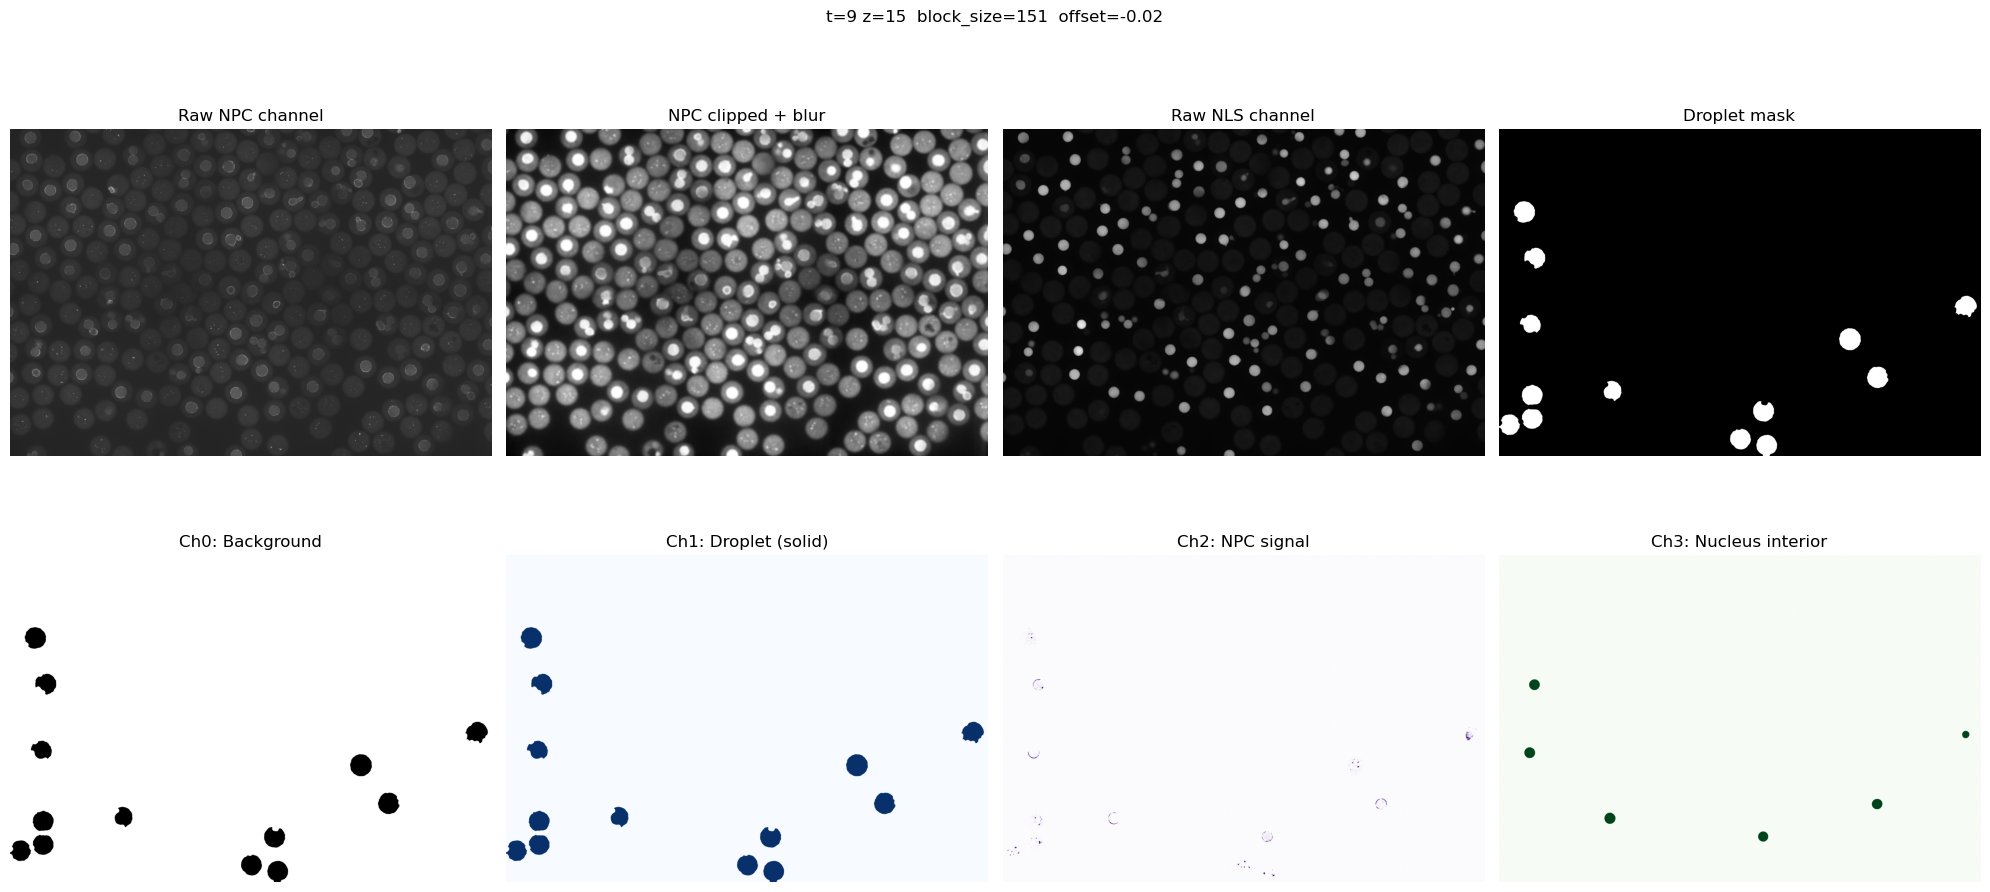

In [7]:
# ============================================================
# 8. QC: build and visualize one training plane
# v8: shows 4-channel multi-label target — verify that:
#   1. Droplet channel (Ch1) is a solid filled circle
#   2. Nucleus pixels are ALSO set in the droplet channel
#   3. Late timepoint (t=9) shows droplets with new params
# ============================================================

t_qc = 9 if img_fov.shape[0] > 9 else img_fov.shape[0] - 1
z_qc = min(15, img_fov.shape[1] - 1)

npc2d = img_fov[t_qc, z_qc, NPC_CH, :, :]
nuc2d = img_fov[t_qc, z_qc, NUC_CH, :, :]

# Use per-timepoint droplet kwargs (t=9 uses tighter params)
dk_qc = cfg.droplet_kwargs_for_timepoint(t_qc)
nk_qc = {
    "min_nucleus_area_um2":    cfg.min_nucleus_area_um2,
    "max_nucleus_area_um2":    cfg.max_nucleus_area_um2,
    "blur_sigma":              cfg.nucleus_blur_sigma,
    "closing_radius_um":       cfg.nucleus_closing_radius_um,
    "hole_area_um2":           cfg.nucleus_hole_area_um2,
}

target_test, metadata_test, debug_test = build_training_label_plane(
    npc2d=npc2d, nuc2d=nuc2d, pixel_size_um=PIXEL_SIZE_UM,
    droplet_kwargs=dk_qc, nucleus_kwargs=nk_qc,
)

print(metadata_test)
if target_test is not None:
    print('Target shape:', target_test.shape, '  dtype:', target_test.dtype)
    for c, name in enumerate(['Background', 'Droplet (full)', 'NPC', 'Nucleus']):
        px = int(target_test[..., c].sum())
        print(f'  Ch{c} {name:16s}: {px:>8,} px')

    # Verify overlap: all nucleus pixels must also be droplet pixels
    nuc_px  = target_test[..., 3] > 0.5
    drop_px = target_test[..., 1] > 0.5
    overlap = int((nuc_px & drop_px).sum())
    nuc_total = int(nuc_px.sum())
    print(f'\nOverlap check: nucleus pixels also in droplet: '
          f'{overlap}/{nuc_total} ({100*overlap/max(nuc_total,1):.1f}%) — should be 100%')

    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    ax[0, 0].imshow(npc2d, cmap="gray");                            ax[0, 0].set_title("Raw NPC channel")
    ax[0, 1].imshow(debug_test["npc_blur"], cmap="gray");           ax[0, 1].set_title("NPC clipped + blur")
    ax[0, 2].imshow(nuc2d, cmap="gray");                            ax[0, 2].set_title("Raw NLS channel")
    ax[0, 3].imshow(debug_test["droplet_mask"], cmap="gray");       ax[0, 3].set_title("Droplet mask")
    cmaps = ['gray', 'Blues', 'Purples', 'Greens']
    names = ['Ch0: Background', 'Ch1: Droplet (solid)', 'Ch2: NPC signal', 'Ch3: Nucleus interior']
    for c in range(4):
        ax[1, c].imshow(target_test[..., c], cmap=cmaps[c], vmin=0, vmax=1)
        ax[1, c].set_title(names[c])
    for a in ax.ravel():
        a.axis("off")
    plt.suptitle(f't={t_qc} z={z_qc}  block_size={dk_qc["local_block_size"]}  offset={dk_qc["local_offset"]}')
    plt.tight_layout()
    plt.show()
else:
    print('Plane excluded:', metadata_test)


In [7]:
# ============================================================
# 9. Patch extraction helpers
# v8: extract_multilabel_patch added for (H, W, 4) targets
# ============================================================

def build_input_patch(mem_patch, nuc_patch, npc_patch):
    """Returns H x W x 3 float32 in [0,1]. Channel order: NLS, NPC, membrane."""
    return np.stack([
        normalize_channel(nuc_patch),
        normalize_channel(npc_patch),
        normalize_channel(mem_patch),
    ], axis=-1).astype('float32')

def clamp_patch_center(cy, cx, height, width, patch_size):
    half = patch_size // 2
    cy = int(np.clip(cy, half, height - half))
    cx = int(np.clip(cx, half, width  - half))
    return cy, cx

def extract_2d_patch(arr2d, cy, cx, patch_size):
    half = patch_size // 2
    return arr2d[cy - half:cy + half, cx - half:cx + half]

def extract_multilabel_patch(target_hwc, cy, cx, patch_size):
    """Extract (patch_size, patch_size, 4) from (H, W, 4) multilabel target."""
    half = patch_size // 2
    return target_hwc[cy - half:cy + half, cx - half:cx + half, :]

def extract_plane_patch(img_fov, t, z, cy, cx, patch_size=cfg.patch_size):
    mem_patch = extract_2d_patch(img_fov[t, z, MEM_CH], cy, cx, patch_size)
    nuc_patch = extract_2d_patch(img_fov[t, z, NUC_CH], cy, cx, patch_size)
    npc_patch = extract_2d_patch(img_fov[t, z, NPC_CH], cy, cx, patch_size)
    return build_input_patch(mem_patch, nuc_patch, npc_patch)

def centers_from_mask(mask, max_centers=None, rng=None):
    rng = rng or np.random.default_rng(SEED)
    labeled = measure.label(mask)
    centers = [(int(r.centroid[0]), int(r.centroid[1])) for r in measure.regionprops(labeled)]
    if max_centers is not None and len(centers) > max_centers:
        idx = rng.choice(len(centers), size=max_centers, replace=False)
        centers = [centers[i] for i in idx]
    return centers

def jitter_center(cy, cx, jitter_px, height, width, patch_size, rng):
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    return clamp_patch_center(cy, cx, height, width, patch_size)

def random_centers_from_mask(mask, n, height, width, patch_size, rng):
    ys, xs = np.where(mask)
    if len(ys) == 0 or n <= 0:
        return []
    idx = rng.choice(len(ys), size=min(n, len(ys)), replace=False)
    return [clamp_patch_center(int(ys[i]), int(xs[i]), height, width, patch_size)
            for i in idx]

def get_completed_timepoints(cfg):
    completed = set()
    for flag in cfg.training_root.glob('t???_complete.flag'):
        try:
            t = int(flag.stem.split('_')[0][1:])
            completed.add(t)
        except (ValueError, IndexError):
            pass
    return completed

def write_timepoint_sentinel(cfg, t, n_patches):
    sentinel = cfg.training_root / f't{t:03d}_complete.flag'
    sentinel.write_text(f't={t} patches={n_patches}')

def clear_timepoint_sentinel(cfg, t):
    sentinel = cfg.training_root / f't{t:03d}_complete.flag'
    if sentinel.exists():
        sentinel.unlink()


In [9]:
# ============================================================
# 10. Build training patches — v8 parallel + multilabel
#
# v8 Issue #2: per-timepoint droplet params via
#   cfg.droplet_kwargs_for_timepoint(t)
#
# v8 Issue #3: ProcessPoolExecutor parallel generation
#   Each timepoint runs as a separate process on its own core.
#   On Linux (fork), child processes inherit all notebook
#   functions. Each worker opens its own tiff.memmap.
#   Resume supported via per-timepoint sentinel files.
#
# Label format: (H, W, 4) float32 binary multi-label
# ============================================================

def _nucleus_kwargs(cfg):
    return {
        "min_nucleus_area_um2":    cfg.min_nucleus_area_um2,
        "max_nucleus_area_um2":    cfg.max_nucleus_area_um2,
        "blur_sigma":              cfg.nucleus_blur_sigma,
        "closing_radius_um":       cfg.nucleus_closing_radius_um,
        "hole_area_um2":           cfg.nucleus_hole_area_um2,
    }


def _process_one_timepoint(args):
    """
    Top-level worker for parallel patch generation (Issue #3).

    Must be a top-level function so it is picklable by ProcessPoolExecutor.
    On Linux with fork context, inherits all notebook-level functions.

    Parameters
    ----------
    args : tuple
        (t, image_path_str, cfg, patch_id_offset, worker_seed)

    Returns
    -------
    list of summary row dicts for this timepoint.
    """
    t, image_path_str, cfg, patch_id_offset, worker_seed = args

    import tifffile as _tiff
    import numpy as _np
    import gc as _gc
    from skimage import measure as _measure

    # Each worker opens its own memmap — safe since read-only
    img_fov_w = _tiff.memmap(image_path_str)
    n_t, n_z, n_c, height, width = img_fov_w.shape

    rng          = _np.random.default_rng(worker_seed)
    summary_rows = []
    patch_id     = patch_id_offset   # unique within this worker's filename space

    dk = cfg.droplet_kwargs_for_timepoint(t)
    nk = _nucleus_kwargs(cfg)

    # Reference droplet layout
    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    if not valid_zs:
        print(f"  t={t}: no valid Z planes, skipping.")
        return []
    ref_z = valid_zs[len(valid_zs) // 2]
    npc_ref = _np.asarray(img_fov_w[t, ref_z, cfg.npc_channel_idx])
    droplet_mask_ref = segment_droplet_from_npc(npc_ref, pixel_size_um=cfg.pixel_size_um, **dk)
    labeled_ref = _measure.label(droplet_mask_ref)
    n_droplets  = len(_np.unique(labeled_ref)) - 1

    if n_droplets == 0:
        print(f"  t={t}: no droplets at ref z={ref_z}, skipping.")
        write_timepoint_sentinel(cfg, t, 0)
        return []

    best_z_per_droplet, focus_channel, nuc_signals = select_best_focus_z_per_droplet(
        img_fov_w, t, droplet_mask_ref,
        erosion_radius_px=cfg.droplet_seed_erosion_px, cfg=cfg)

    n_accepted  = len(best_z_per_droplet)
    n_patches_t = cfg.patches_for_timepoint(t)
    block_used  = dk['local_block_size']
    print(f"  t={t}: ref_z={ref_z}  channel={focus_channel!r}  "
          f"{n_accepted}/{n_droplets} droplets accepted  "
          f"patches_per_droplet={n_patches_t}  block_size={block_used}", flush=True)

    z_to_droplets = {}
    for did, bz in best_z_per_droplet.items():
        z_to_droplets.setdefault(bz, []).append(did)

    region_centroids = {
        int(r.label): (int(r.centroid[0]), int(r.centroid[1]))
        for r in _measure.regionprops(labeled_ref)
    }

    for z, droplet_ids in z_to_droplets.items():
        npc2d = _np.asarray(img_fov_w[t, z, cfg.npc_channel_idx])
        nuc2d = _np.asarray(img_fov_w[t, z, cfg.nucleus_channel_idx])

        # v8: build_training_label_plane now returns (H,W,4) multilabel target
        target, metadata, debug = build_training_label_plane(
            npc2d=npc2d, nuc2d=nuc2d,
            pixel_size_um=cfg.pixel_size_um,
            use_focus_filter=False,
            droplet_kwargs=dk,
            nucleus_kwargs=nk,
        )
        if target is None:
            continue
        if debug['droplet_mask'].sum() == 0:
            del target, debug; _gc.collect()
            continue

        for did in droplet_ids:
            if did not in region_centroids:
                continue
            cy_base, cx_base = region_centroids[did]
            patches_saved = 0

            for _ in range(n_patches_t):
                cy, cx = jitter_center(
                    cy_base, cx_base,
                    cfg.patch_jitter_px, height, width, cfg.patch_size, rng)

                # v8: extract (H, W, 4) multilabel patch
                y_patch = extract_multilabel_patch(target, cy, cx, cfg.patch_size)
                if y_patch.shape[:2] != (cfg.patch_size, cfg.patch_size):
                    continue
                # min_label_fraction check on droplet channel (ch1)
                if _np.mean(y_patch[..., 1] > 0) < cfg.min_label_fraction:
                    continue

                x_patch = extract_plane_patch(img_fov_w, t, z, cy, cx, cfg.patch_size)
                stem = (f"t{t:03d}_z{z:03d}_d{did:04d}"
                        f"_y{cy:04d}_x{cx:04d}_p{patch_id:06d}")
                # v8: labels saved as float32 (H, W, 4)
                _np.save(cfg.image_patch_dir / f'img_{stem}.npy', x_patch.astype('float32'))
                _np.save(cfg.label_patch_dir / f'lab_{stem}.npy', y_patch.astype('float32'))
                patch_id     += 1
                patches_saved += 1

            summary_rows.append({
                "t": t, "z": z, "droplet_id": did,
                "focus_channel":            focus_channel,
                "patch_type":               "focus_selected",
                "nucleus_signal_at_best_z": nuc_signals.get(did, float('nan')),
                "npc_area_px":              int(debug["npc_mask"].sum()),
                "nucleus_area_px":          int(debug["nucleus_mask"].sum()),
                "droplet_area_px":          int(debug["droplet_mask"].sum()),
                "patches_saved":            patches_saved,
            })

        del target, debug; _gc.collect()

    # Coverslip hard-negative patches
    if cfg.coverslip_negative_patches_per_t > 0 and t <= cfg.coverslip_neg_max_t:
        neg_rows, n_neg = _sample_coverslip_negatives_multilabel(
            img_fov_w, t, cfg, rng, patch_id, dk)
        summary_rows.extend(neg_rows)
        patch_id += n_neg
        print(f"    coverslip negatives: {n_neg} patches", flush=True)

    t_patches = sum(r.get('patches_saved', 0) for r in summary_rows if r.get('t') == t)
    write_timepoint_sentinel(cfg, t, t_patches)
    print(f"  t={t}: sentinel written ({t_patches} patches total)", flush=True)
    return summary_rows


def _sample_coverslip_negatives_multilabel(img_fov_w, t, cfg, rng, patch_id_start, dk):
    """
    v8: Coverslip hard-negative patches with (H, W, 4) multilabel labels.
    Channels 2 (NPC) and 3 (nucleus) are forced to 0 — biological assertion.
    """
    n_t, n_z, n_c, height, width = img_fov_w.shape
    patch_id = patch_id_start
    rows = []
    z_floor     = cfg.edge_z_exclusion if cfg.exclude_edge_z_planes else 0
    coverslip_zs = [z for z in range(z_floor, cfg.coverslip_z_max) if z < n_z]
    if not coverslip_zs:
        return rows, 0

    patches_saved = 0
    attempts      = 0
    max_attempts  = cfg.coverslip_negative_patches_per_t * 10

    while patches_saved < cfg.coverslip_negative_patches_per_t and attempts < max_attempts:
        attempts += 1
        z     = int(rng.choice(coverslip_zs))
        npc2d = np.asarray(img_fov_w[t, z, cfg.npc_channel_idx])

        droplet_mask = segment_droplet_from_npc(npc2d, pixel_size_um=cfg.pixel_size_um, **dk)
        if not droplet_mask.any():
            continue

        # v8 multilabel: droplet only, NPC and nucleus forced 0
        target_neg = np.zeros((height, width, 4), dtype=np.float32)
        target_neg[..., 0] = (~droplet_mask).astype(np.float32)  # background
        target_neg[..., 1] = droplet_mask.astype(np.float32)     # droplet only
        # ch2 (NPC) and ch3 (nucleus) remain 0

        labeled_cs = measure.label(droplet_mask)
        regions    = measure.regionprops(labeled_cs)
        if not regions:
            continue
        region  = regions[int(rng.integers(0, len(regions)))]
        cy_base = int(region.centroid[0])
        cx_base = int(region.centroid[1])
        cy, cx = jitter_center(
            cy_base, cx_base, cfg.patch_jitter_px,
            height, width, cfg.patch_size, rng)

        y_patch = extract_multilabel_patch(target_neg, cy, cx, cfg.patch_size)
        if y_patch.shape[:2] != (cfg.patch_size, cfg.patch_size):
            continue
        if np.mean(y_patch[..., 1] > 0) < cfg.min_label_fraction:
            continue

        x_patch = extract_plane_patch(img_fov_w, t, z, cy, cx, cfg.patch_size)
        nuc_patch_norm = normalize_01(x_patch[..., 0])
        if float(np.mean(nuc_patch_norm)) < cfg.coverslip_min_brightness:
            continue

        stem = (f"t{t:03d}_z{z:03d}_cneg"
                f"_y{cy:04d}_x{cx:04d}_p{patch_id:06d}")
        np.save(cfg.image_patch_dir / f'img_{stem}.npy', x_patch.astype('float32'))
        np.save(cfg.label_patch_dir / f'lab_{stem}.npy', y_patch.astype('float32'))
        patch_id     += 1
        patches_saved += 1

        rows.append({
            't': t, 'z': z, 'droplet_id': int(region.label),
            'focus_channel': 'coverslip_negative',
            'patch_type':    'coverslip_negative',
            'nucleus_area_px': 0,
            'droplet_area_px': int(droplet_mask.sum()),
            'patches_saved':   1,
        })

    return rows, patches_saved


def build_training_patches_parallel(img_fov, cfg=cfg, overwrite=False):
    """
    v8 parallel patch builder (Issue #3).

    Runs all timepoints simultaneously via ProcessPoolExecutor.
    Each worker gets its own process, its own memmap handle, and
    a unique RNG seed (cfg.seed + t) for reproducibility.

    Patch ID namespace: t * 100000 offset per worker ensures unique
    filenames since stems include t{t:03d} anyway.

    On Cheaha: set SLURM --cpus-per-task=10 (or cfg.max_parallel_workers).
    On local machine: limited by os.cpu_count().
    """
    if overwrite:
        for d in [cfg.image_patch_dir, cfg.label_patch_dir]:
            if d.exists():
                shutil.rmtree(d)
            d.mkdir(parents=True, exist_ok=True)
        for flag in cfg.training_root.glob('t???_complete.flag'):
            flag.unlink()

    cfg.image_patch_dir.mkdir(parents=True, exist_ok=True)
    cfg.label_patch_dir.mkdir(parents=True, exist_ok=True)

    n_t = img_fov.shape[0]
    completed_t = get_completed_timepoints(cfg) if not overwrite else set()
    if completed_t:
        print(f'Resuming — skipping completed timepoints: {sorted(completed_t)}')

    pending_t = [t for t in range(n_t) if t not in completed_t]
    if not pending_t:
        print('All timepoints already complete.')
    else:
        image_path_str = str(cfg.image_file)
        max_workers = min(len(pending_t), cfg.max_parallel_workers, os.cpu_count() or 1)
        print(f'Launching {len(pending_t)} timepoints on {max_workers} workers...')
        print(f'Timepoints to process: {pending_t}')

        # Build args for each worker
        # patch_id_offset = t * 100000 guarantees no filename collision
        # worker_seed     = cfg.seed + t for reproducibility
        worker_args = [
            (t, image_path_str, cfg, t * 100000, cfg.seed + t)
            for t in pending_t
        ]

        all_summary_rows = []
        # Use fork context on Linux — child processes inherit notebook functions
        ctx = multiprocessing.get_context('fork')
        with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
            futures = {executor.submit(_process_one_timepoint, args): args[0]
                       for args in worker_args}
            for future in as_completed(futures):
                t_done = futures[future]
                try:
                    rows = future.result()
                    all_summary_rows.extend(rows)
                    t_count = sum(r.get('patches_saved', 0) for r in rows if r.get('t') == t_done)
                    print(f'  t={t_done} finished: {t_count} patches')
                except Exception as exc:
                    print(f'  t={t_done} FAILED: {exc}')

    # Build summary from all saved patches (covers resumed + newly generated)
    all_patch_files = sorted(cfg.image_patch_dir.glob('img_t*.npy'))
    total_patches   = len(all_patch_files)

    # Reconstruct summary from filenames if needed
    try:
        summary_rows = all_summary_rows
    except NameError:
        summary_rows = []

    summary_df   = pd.DataFrame(summary_rows) if summary_rows else pd.DataFrame()
    summary_path = cfg.training_root / "training_patch_summary_v8.csv"
    summary_df.to_csv(summary_path, index=False)

    print(f"\nTotal patches on disk : {total_patches}")
    print(f"Summary CSV           : {summary_path}")
    if not summary_df.empty:
        print("\nPer-timepoint patch counts:")
        for tt in sorted(summary_df['t'].unique()):
            sub = summary_df[summary_df['t'] == tt]
            fs = int(sub[sub.get('patch_type', pd.Series(['focus_selected'])) == 'focus_selected']['patches_saved'].sum()
                     if 'patch_type' in sub.columns else sub['patches_saved'].sum())
            cn = int(sub[sub.get('patch_type', pd.Series([''])) == 'coverslip_negative']['patches_saved'].sum()
                     if 'patch_type' in sub.columns else 0)
            print(f"  t={tt}: {fs} focus-selected  {cn} coverslip-negative")
    return summary_df


# ── Run patch generation ──────────────────────────────────────────────────
# Run Section 5c QC first to verify per-timepoint parameter overrides.
# Set overwrite=True for first run; False to resume from sentinels.
summary_df = build_training_patches_parallel(img_fov, cfg=cfg, overwrite=True)


Launching 10 timepoints on 10 workers...
Timepoints to process: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  t=7: no droplets at ref z=12, skipping.
  t=7 finished: 0 patches
  t=9: ref_z=12  channel='npc_ring'  1/1 droplets accepted  patches_per_droplet=15  block_size=151
  t=6: ref_z=12  channel='npc_ring'  1/1 droplets accepted  patches_per_droplet=9  block_size=151
  t=8: ref_z=12  channel='npc_ring'  1/1 droplets accepted  patches_per_droplet=12  block_size=151
  t=4: ref_z=12  channel='npc_ring'  76/76 droplets accepted  patches_per_droplet=3  block_size=301
  t=5: ref_z=12  channel='npc_ring'  54/54 droplets accepted  patches_per_droplet=6  block_size=301
  t=3: ref_z=12  channel='npc_ring'  100/100 droplets accepted  patches_per_droplet=2  block_size=301
  t=2: ref_z=12  channel='npc_ring'  118/118 droplets accepted  patches_per_droplet=2  block_size=301
  t=1: ref_z=12  channel='nucleus_laplacian'  143/144 droplets accepted  patches_per_droplet=1  block_size=301
  t=0: ref_z=12  channel='

In [11]:
# Check focus-selected patches only (no cneg)
t_check = 3
lab_files_focus = sorted([
    f for f in cfg.label_patch_dir.glob(f'lab_t{t_check:03d}_*.npy')
    if 'cneg' not in f.name
])
print(f"t={t_check}: {len(lab_files_focus)} focus-selected patches")

for lf in lab_files_focus[:10]:
    y = np.load(lf)
    frac = float(np.mean(y[..., 1] > 0))
    print(f"  {lf.name}: droplet_frac={frac:.4f}")

t=3: 23 focus-selected patches
  lab_t003_z009_d0042_y2141_x2656_p300016.npy: droplet_frac=0.0429
  lab_t003_z009_d0088_y3389_x3128_p300017.npy: droplet_frac=0.0055
  lab_t003_z009_d0089_y3475_x2968_p300018.npy: droplet_frac=0.0494
  lab_t003_z009_d0098_y3633_x2992_p300019.npy: droplet_frac=0.1490
  lab_t003_z009_d0098_y3633_x3007_p300020.npy: droplet_frac=0.1619
  lab_t003_z009_d0099_y3633_x3067_p300022.npy: droplet_frac=0.1977
  lab_t003_z009_d0099_y3633_x3084_p300021.npy: droplet_frac=0.1979
  lab_t003_z017_d0001_y0256_x3295_p300001.npy: droplet_frac=0.1135
  lab_t003_z017_d0001_y0271_x3307_p300000.npy: droplet_frac=0.1204
  lab_t003_z017_d0009_y0699_x3427_p300003.npy: droplet_frac=0.0385


Found 729 image patches and 729 label patches.


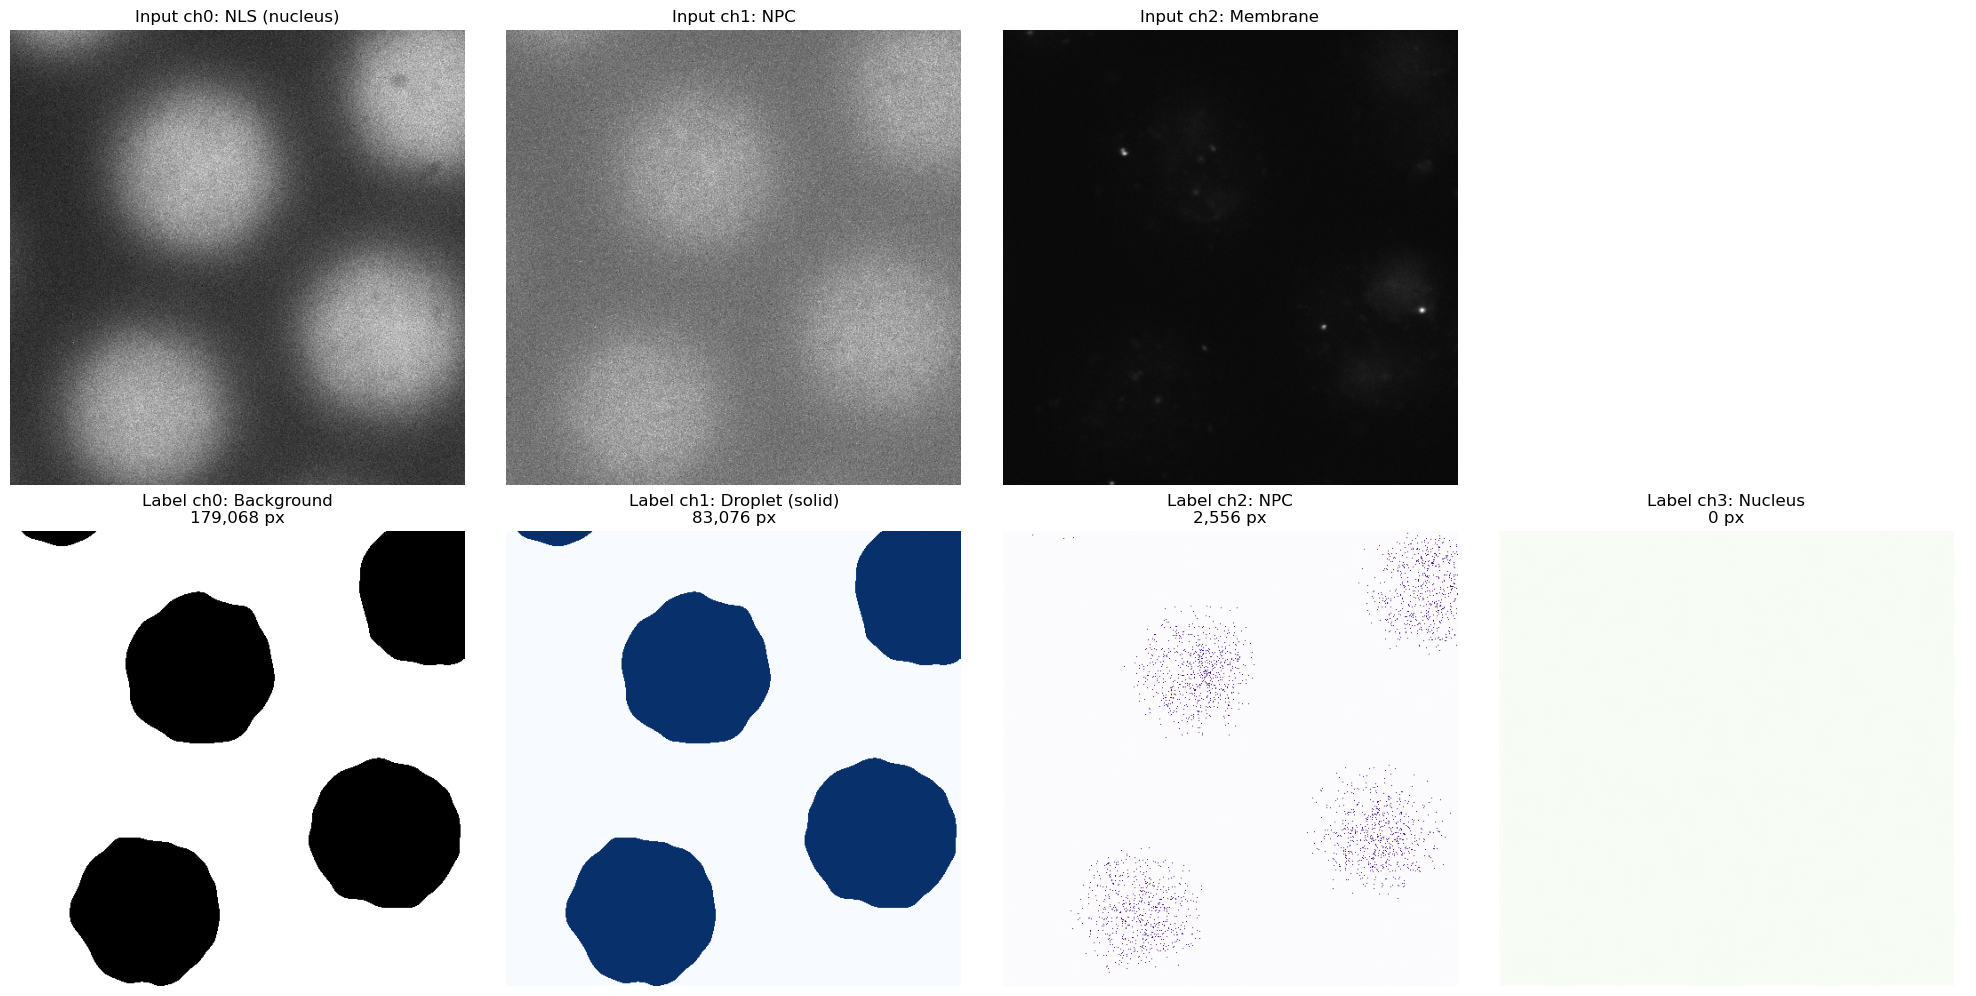

img_t001_z016_d0028_y1243_x4503_p100010.npy
Nucleus pixels also in droplet channel: 0/0 (0.0%) — should be 100%
Holes in droplet channel where nucleus present: 0 — should be 0


In [10]:
# ============================================================
# 11. Patch QC
# v8: displays all 4 label channels and verifies overlap
# ============================================================

def list_patch_files(cfg=cfg):
    img_paths = sorted(cfg.image_patch_dir.glob('*.npy'))
    lab_paths = sorted(cfg.label_patch_dir.glob('*.npy'))
    print(f"Found {len(img_paths)} image patches and {len(lab_paths)} label patches.")
    return img_paths, lab_paths


def show_random_patch(cfg=cfg, seed=SEED):
    img_paths, lab_paths = list_patch_files(cfg)
    if not img_paths:
        print("No patches found. Run build_training_patches_parallel first.")
        return
    rng = np.random.default_rng(seed)
    i   = int(rng.integers(0, len(img_paths)))
    x   = np.load(img_paths[i])   # (H, W, 3)
    y   = np.load(lab_paths[i])   # (H, W, 4) float32

    fig, ax = plt.subplots(2, 4, figsize=(20, 10))
    ax[0, 0].imshow(x[..., 0], cmap="gray");  ax[0, 0].set_title("Input ch0: NLS (nucleus)")
    ax[0, 1].imshow(x[..., 1], cmap="gray");  ax[0, 1].set_title("Input ch1: NPC")
    ax[0, 2].imshow(x[..., 2], cmap="gray");  ax[0, 2].set_title("Input ch2: Membrane")
    ax[0, 3].axis('off')

    cmaps = ['gray', 'Blues', 'Purples', 'Greens']
    names = ['Label ch0: Background', 'Label ch1: Droplet (solid)', 'Label ch2: NPC', 'Label ch3: Nucleus']
    for c in range(4):
        ax[1, c].imshow(y[..., c], cmap=cmaps[c], vmin=0, vmax=1)
        px = int(y[..., c].sum())
        ax[1, c].set_title(f"{names[c]}\n{px:,} px")

    for a in ax.ravel():
        a.axis("off")
    plt.tight_layout()
    plt.show()
    print(img_paths[i].name)

    # Overlap verification
    nuc_px  = y[..., 3] > 0.5
    drop_px = y[..., 1] > 0.5
    overlap = int((nuc_px & drop_px).sum())
    nuc_total = int(nuc_px.sum())
    print(f"Nucleus pixels also in droplet channel: {overlap}/{nuc_total} "
          f"({100*overlap/max(nuc_total,1):.1f}%) — should be 100%")
    # Verify droplet channel has no holes inside nucleus region
    holes = int((nuc_px & ~drop_px).sum())
    print(f"Holes in droplet channel where nucleus present: {holes} — should be 0")


show_random_patch(cfg)


In [ ]:
# ============================================================
# 12. TensorFlow dataset — multi-label sigmoid targets
# v8: labels are (H, W, 4) float32 — no one_hot encoding needed
# ============================================================

def augment_pair(image, label):
    """Identical random flip + rotation applied to image and (H, W, 4) label."""
    n_img_ch = image.shape[-1]   # 3
    n_lab_ch = label.shape[-1]   # 4
    combined = tf.concat([image, label], axis=-1)  # (H, W, 7)
    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)
    k        = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    combined = tf.image.rot90(combined, k=k)
    return combined[..., :n_img_ch], combined[..., n_img_ch:]


def load_npy_pair_py(img_path, lab_path):
    img_path = img_path.item() if isinstance(img_path, np.ndarray) else img_path
    lab_path = lab_path.item() if isinstance(lab_path, np.ndarray) else lab_path
    if isinstance(img_path, bytes): img_path = img_path.decode('utf-8')
    if isinstance(lab_path, bytes): lab_path = lab_path.decode('utf-8')
    x = np.load(img_path).astype('float32')   # (H, W, 3)
    y = np.load(lab_path).astype('float32')   # (H, W, 4) — already binary float32
    return x, y


def tf_load_npy_pair(img_path, lab_path):
    img_arr, lab_arr = tf.numpy_function(
        load_npy_pair_py, [img_path, lab_path], [tf.float32, tf.float32])
    img_arr.set_shape((cfg.patch_size, cfg.patch_size, cfg.n_channels))
    lab_arr.set_shape((cfg.patch_size, cfg.patch_size, cfg.num_classes))  # (H,W,4)
    return img_arr, lab_arr


def make_dataset(img_paths, lab_paths, batch_size=cfg.batch_size,
                 shuffle=True, augment=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (list(map(str, img_paths)), list(map(str, lab_paths))))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths), seed=cfg.seed,
                        reshuffle_each_iteration=True)
    ds = ds.map(tf_load_npy_pair, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def build_train_val_datasets(cfg=cfg):
    img_paths, lab_paths = list_patch_files(cfg)
    if len(img_paths) != len(lab_paths):
        raise ValueError(f'Image/label count mismatch: {len(img_paths)} vs {len(lab_paths)}')
    if len(img_paths) == 0:
        raise ValueError('No patches found. Run patch generation first.')

    val_timepoints = (list(cfg.val_timepoints) if cfg.val_timepoints is not None
                      else [img_fov.shape[0] - 1])
    val_t_strs = [f'_t{t:03d}_' for t in val_timepoints]
    print(f'Validation timepoints : {val_timepoints}')
    print(f'Augmentation          : {cfg.use_augmentation}')

    train_img, train_lab, val_img, val_lab = [], [], [], []
    for ip, lp in zip(img_paths, lab_paths):
        if '_cneg_' in ip.name:
            train_img.append(ip); train_lab.append(lp); continue
        if any(s in ip.name for s in val_t_strs):
            val_img.append(ip); val_lab.append(lp)
        else:
            train_img.append(ip); train_lab.append(lp)

    if len(val_img) == 0:
        raise ValueError(f'No patches matched val_timepoints={val_timepoints}.')

    print(f'Train patches : {len(train_img)}')
    print(f'Val patches   : {len(val_img)}')

    train_ds = make_dataset(train_img, train_lab, cfg.batch_size,
                            shuffle=True, augment=cfg.use_augmentation)
    val_ds   = make_dataset(val_img,   val_lab,   cfg.batch_size,
                            shuffle=False, augment=False)
    return train_ds, val_ds, train_img, val_img


train_ds, val_ds, train_img_paths, val_img_paths = build_train_val_datasets(cfg)


In [ ]:
# ============================================================
# 13. U-Net model
# v8: output activation changed softmax -> sigmoid
# Each of the 4 channels is an independent binary prediction.
# ============================================================

def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if dropout_rate > 0.0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x

def encoder_block(x, filters, dropout_rate=0.0):
    c = conv_block(x, filters, dropout_rate=dropout_rate)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p

def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate=dropout_rate)
    return x

def build_unet(input_shape=None, num_classes=None):
    if input_shape is None:
        input_shape = (cfg.patch_size, cfg.patch_size, cfg.n_channels)
    if num_classes is None:
        num_classes = cfg.num_classes

    inputs = layers.Input(shape=input_shape)
    c1, p1 = encoder_block(inputs, 32,  dropout_rate=0.0)
    c2, p2 = encoder_block(p1,     64,  dropout_rate=0.0)
    c3, p3 = encoder_block(p2,     128, dropout_rate=0.0)
    c4, p4 = encoder_block(p3,     256, dropout_rate=0.0)
    bn     = conv_block(p4, 512, dropout_rate=0.5)
    d1     = decoder_block(bn, c4, 256, dropout_rate=0.3)
    d2     = decoder_block(d1, c3, 128, dropout_rate=0.3)
    d3     = decoder_block(d2, c2, 64,  dropout_rate=0.0)
    d4     = decoder_block(d3, c1, 32,  dropout_rate=0.0)

    # v8: sigmoid — each channel is an independent binary segmentation
    # A pixel can be class 1 (droplet) AND class 3 (nucleus) simultaneously
    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)
    return models.Model(inputs, outputs, name=cfg.model_name)


model = build_unet()
model.summary()


In [ ]:
# ============================================================
# 14. Loss, metrics, callbacks, training
# v8: binary cross-entropy + per-class Dice loss
# Metrics use sigmoid > 0.5 threshold instead of argmax
# droplet_dice added to track solid droplet prediction
# ============================================================

_CLASS_WEIGHTS = tf.constant(list(cfg.loss_class_weights), dtype=tf.float32)


def weighted_binary_dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Per-class Dice loss for multi-label sigmoid outputs.
    Each channel is an independent binary segmentation.
    Weighted by loss_class_weights.
    """
    axes = [0, 1, 2]  # batch + spatial, keep class axis
    intersection   = tf.reduce_sum(y_true * y_pred,      axis=axes)  # (4,)
    denom          = tf.reduce_sum(y_true + y_pred,       axis=axes)  # (4,)
    dice_per_class = (2.0 * intersection + smooth) / (denom + smooth)
    weighted_mean  = (tf.reduce_sum(_CLASS_WEIGHTS * dice_per_class) /
                      tf.reduce_sum(_CLASS_WEIGHTS))
    return 1.0 - weighted_mean


def weighted_binary_ce_loss(y_true, y_pred):
    """
    Per-pixel binary cross-entropy with per-class weighting.
    Computed per channel independently.
    """
    eps = 1e-7
    y_pred_clipped = tf.clip_by_value(y_pred, eps, 1.0 - eps)
    bce = -(y_true * tf.math.log(y_pred_clipped) +
            (1.0 - y_true) * tf.math.log(1.0 - y_pred_clipped))  # (B, H, W, 4)
    weighted = bce * _CLASS_WEIGHTS  # broadcast over (B, H, W)
    return tf.reduce_mean(weighted)


def combined_weighted_loss(y_true, y_pred):
    """Primary loss: weighted binary CE + weighted binary Dice."""
    return weighted_binary_ce_loss(y_true, y_pred) + weighted_binary_dice_loss(y_true, y_pred)


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Mean Dice across all 4 classes."""
    y_pred_bin   = tf.cast(y_pred > 0.5, tf.float32)
    axes         = [0, 1, 2]
    intersection = tf.reduce_sum(y_true * y_pred_bin, axis=axes)
    denom        = tf.reduce_sum(y_true + y_pred_bin, axis=axes)
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))


def npc_dice(y_true, y_pred, smooth=1e-6):
    """Dice for NPC class (channel 2) — primary detection metric."""
    y_true_c = y_true[..., 2]
    y_pred_c = tf.cast(y_pred[..., 2] > 0.5, tf.float32)
    inter    = tf.reduce_sum(y_true_c * y_pred_c)
    denom    = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2.0 * inter + smooth) / (denom + smooth)


def nucleus_dice(y_true, y_pred, smooth=1e-6):
    """Dice for nucleus interior (channel 3) — measurement ROI metric."""
    y_true_c = y_true[..., 3]
    y_pred_c = tf.cast(y_pred[..., 3] > 0.5, tf.float32)
    inter    = tf.reduce_sum(y_true_c * y_pred_c)
    denom    = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2.0 * inter + smooth) / (denom + smooth)


def droplet_dice(y_true, y_pred, smooth=1e-6):
    """
    Dice for droplet interior (channel 1).
    With solid multilabel labels this should now be high.
    Low droplet_dice indicates the model still sees a patchy droplet.
    """
    y_true_c = y_true[..., 1]
    y_pred_c = tf.cast(y_pred[..., 1] > 0.5, tf.float32)
    inter    = tf.reduce_sum(y_true_c * y_pred_c)
    denom    = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c)
    return (2.0 * inter + smooth) / (denom + smooth)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.learning_rate),
    loss=combined_weighted_loss,
    metrics=[dice_coefficient, npc_dice, nucleus_dice, droplet_dice],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(cfg.best_model_path),
        monitor="val_npc_dice",
        save_best_only=True, mode='max', verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_npc_dice",
        factor=0.5, patience=4, min_delta=1e-4, mode='max', verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_npc_dice",
        patience=10, restore_best_weights=True, mode='max', verbose=1,
    ),
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=cfg.epochs, callbacks=callbacks)
model.save(cfg.final_model_path)


In [ ]:
# ============================================================
# 15. Training history visualization
# v8: includes droplet_dice — should be high with solid labels
# ============================================================

def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history.history["loss"],     label="Train loss")
    axes[0].plot(history.history["val_loss"], label="Val loss")
    axes[0].set_title("Combined weighted loss (binary BCE + Dice)")
    axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(history.history["dice_coefficient"],     label="Train mean Dice")
    axes[1].plot(history.history["val_dice_coefficient"], label="Val mean Dice")
    axes[1].plot(history.history["npc_dice"],             label="Train NPC Dice",    linestyle="--")
    axes[1].plot(history.history["val_npc_dice"],         label="Val NPC Dice",      linestyle="--")
    axes[1].plot(history.history["nucleus_dice"],         label="Train nucleus Dice", linestyle=":")
    axes[1].plot(history.history["val_nucleus_dice"],     label="Val nucleus Dice",   linestyle=":")
    axes[1].plot(history.history["droplet_dice"],         label="Train droplet Dice", linestyle="-.")
    axes[1].plot(history.history["val_droplet_dice"],     label="Val droplet Dice",   linestyle="-.")
    axes[1].set_title("Per-class Dice metrics (all sigmoid-thresholded)")
    axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7)

    axes[2].set_title("Class weights reference")
    class_names = ['Background', 'Droplet', 'NPC', 'Nucleus']
    axes[2].bar(class_names, cfg.loss_class_weights,
                color=['gray', 'steelblue', 'purple', 'green'])
    axes[2].set_ylabel("Weight")

    plt.tight_layout(); plt.show()


plot_training_history(history)


In [ ]:
# ============================================================
# 16. Visualize validation predictions
# v8: shows per-channel sigmoid probability maps
# Key check: droplet prediction should be solid (no holes)
# ============================================================

def show_prediction_batch(model, dataset, n=2, threshold=0.5):
    for x_batch, y_batch in dataset.take(1):
        preds = model.predict(x_batch)  # (B, H, W, 4) sigmoid outputs
        n_show = min(n, x_batch.shape[0])

        for i in range(n_show):
            fig, axes = plt.subplots(3, 4, figsize=(20, 15))

            # Row 1: input channels
            axes[0, 0].imshow(x_batch[i, ..., 0], cmap="gray"); axes[0, 0].set_title("Input: NLS")
            axes[0, 1].imshow(x_batch[i, ..., 1], cmap="gray"); axes[0, 1].set_title("Input: NPC")
            axes[0, 2].imshow(x_batch[i, ..., 2], cmap="gray"); axes[0, 2].set_title("Input: Membrane")
            axes[0, 3].axis('off')

            # Row 2: true multi-label channels
            cmaps = ['gray', 'Blues', 'Purples', 'Greens']
            true_names = ['True: Background', 'True: Droplet (solid)', 'True: NPC', 'True: Nucleus']
            for c in range(4):
                axes[1, c].imshow(y_batch[i, ..., c], cmap=cmaps[c], vmin=0, vmax=1)
                axes[1, c].set_title(true_names[c])

            # Row 3: predicted probability maps
            pred_names = ['Pred: Background', 'Pred: Droplet', 'Pred: NPC', 'Pred: Nucleus']
            for c in range(4):
                im = axes[2, c].imshow(preds[i, ..., c], cmap=cmaps[c], vmin=0, vmax=1)
                plt.colorbar(im, ax=axes[2, c], fraction=0.03)
                axes[2, c].set_title(
                    f"{pred_names[c]}\nmax={preds[i,...,c].max():.3f}")

            for a in axes.ravel():
                a.axis("off")

            # Overlap check: nucleus pred should be inside droplet pred
            drop_pred = (preds[i, ..., 1] > threshold)
            nuc_pred  = (preds[i, ..., 3] > threshold)
            holes = int((nuc_pred & ~drop_pred).sum())
            print(f"Sample {i}: nucleus predictions NOT in droplet prediction = {holes} "
                  f"(should be ~0 with correct multilabel training)")

            plt.tight_layout(); plt.show()
        break


show_prediction_batch(model, val_ds, n=2)


## 17. SLURM job script reference

For parallel patch generation on Cheaha, request enough CPUs so each timepoint gets its own core:

```bash
#!/bin/bash
#SBATCH --job-name=v8_patches
#SBATCH --partition=amperenodes
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=10
#SBATCH --mem=120G
#SBATCH --gres=gpu:1
#SBATCH --time=08:00:00
#SBATCH --output=v8_patches_%j.out

module load Anaconda3
conda activate ml_env_tf_2.15
export LD_LIBRARY_PATH=$CONDA_PREFIX/lib:$LD_LIBRARY_PATH

jupyter nbconvert --to notebook --execute Nuclear_Segmentation_v8.ipynb \
  --ExecutePreprocessor.timeout=28800
```

**Key parameters:**
- `--cpus-per-task=10` — one core per timepoint (10 timepoints)
- `--mem=120G` — ~12GB per worker for large FOV memmap + segmentation
- `--gres=gpu:1` — required for training phase after patch generation

`cfg.max_parallel_workers` is automatically set from `SLURM_CPUS_PER_TASK` at runtime.
